## To Do List
  1. Constructing the exact BW peaks
  2. Constructing the training data - correlators with noise
  3. Preparing the two NN representations
  4. Writing the Training loops
  5. Implementing the two losses with $\rho(\omega)$ the reconstructed spectral function and $\tilde{\rho}(\omega)$ - the ground truth
      - MSE with $\int^{\infty}_0 \left(\tilde{\rho}(\omega) - \rho(\omega) \right)$
      - DKL with $\int^{\infty}_0 \rho(\omega) \log \left( \frac{\rho(\omega)}{\tilde{\rho}(\omega)} \right)$
  7. Re-run the code with different instances of noice for $D(p_i)$ and perform a Jacknife analysis estimating the propagation of errors on $\rho (\omega)$

The BW peaks to be tested are the single and double as used in [this paper](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.106.L051502) , Section IV. Important details on the Training setups and Mock lattice data preparation are given in this [Supplemental paper](https://journals.aps.org/prd/supplemental/10.1103/PhysRevD.106.L051502/supplementary_material.pdf)

$\rho^{(BW)}(\omega) = \frac{4 A \Gamma \omega}{\left(M^2 + \Gamma^2 - \omega^2 \right)^2 + 4 \Gamma^2 \omega^2}$, with 
- $A=1.0$, $\Gamma=0.5$, $M=2.0$
- $A_1 = 0.8$, $A_2 = 1.0$,  $\Gamma_1=\Gamma_2=0.5$, $M_1=2.0$, $M_2=5.0$

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import tensorflow as tf
import keras
import correlator
import physicsHelper
import lossCalculator
import models

2024-11-29 10:16:13.782892: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-29 10:16:13.790629: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-29 10:16:13.874247: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-29 10:16:13.947131: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1732871774.018981   12566 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1732871774.04

In [2]:
## Constructing the exact BW peaks
##Single peak
A = np.array([1.0])
Ga = np.array([0.5])
M = np.array([2.0])
##Double peak
A = np.array([0.8,1.0])
Ga = np.array([0.5,0.5])
M = np.array([2.0,5.0])
#List of frequencies 
omega = np.linspace(0,19.96,500)
del_omega = omega[1]-omega[0]

(0.0, 10.0)

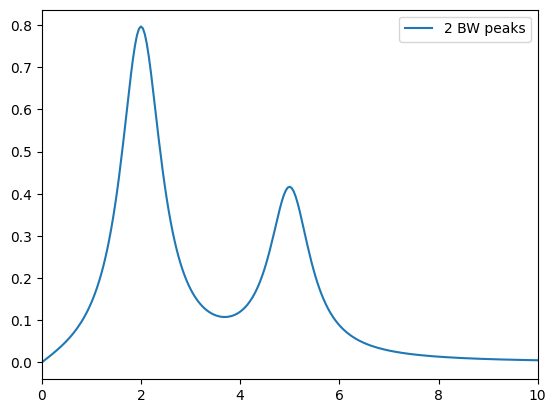

In [3]:
##Depending on which list you choose construct and save the spec_func as below and comment them out
#spec1BW = BWfun(A,Ga,M,omega)
spec2BW = physicsHelper.BWfun(A,Ga,M,omega)

# plt.plot(omega,spec1BW,label=r'1 BW peak')
plt.plot(omega,spec2BW, label=r'2 BW peaks')
#plt.plot(omega,spec3BW, label=r'3 BW peaks')

plt.legend()
plt.xlim(0,10)


In [4]:
epsilon = 0 #This epsilon controls momentum close to 0 so that kernel doesnt have zero eigenvalues
x = np.linspace(epsilon,19.2+epsilon,25)
del_xi = x[1]-x[0]

# kl_ker=correlator.KL_kernel_Momentum(x,omega)
# klW_ker=correlator.KL_kernel_Omega(correlator.KL_kernel_Momentum,p,omega)
kl_ker_Pos=correlator.KL_kernel_Position_Vacuum(x,omega)
klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)

##Again Dpi can represent both 1BW or 2BW depending on whether you pass spec1W or spec2W - Be careful!
Dxi = correlator.Di(kl_ker_Pos,spec2BW,del_omega)

2024-11-29 10:16:15.443013: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In the cell below, the main training is taking place - feel free to change the following parameters for the experiment:
- lambda_s
- lambda_l2
- epochs both in warm-up and training loops
- learning rates both in warm-up and training loops
- gauss_width between all ones and the relative error on Dp_i

One can also change the number of hidden layers or the width of each layer but care has to be taken in order not to induce syntax errors 

When you makes changes - you only need to re-run the cell below for re-training. 

# New
Either main_loss becomes a vector corresponding to different target_outputs diff noisy_Dpi
The idea is that yPred should fit many correlator instances 
We do this for each epoch - minimise over different targets. After the epoch loop - put a noisy Dpi loop
   

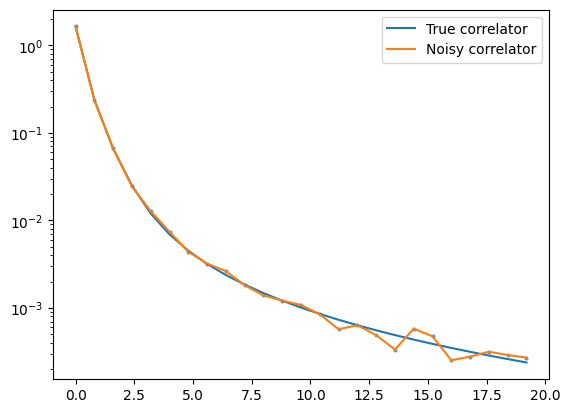

In [5]:
# Preparing the tensor of noise vectors
ep_noise=1e-2
noisy_dxi_tensor = []
num_samples = 1
noisy_Dxi,custom_std=correlator.generateNoisyCorrelator(Dxi,x,ep_noise)
if num_samples == 1:
    noisy_dxi_tensor.append(noisy_Dxi)
else:
    for ii in range(num_samples):
        noisy_Dxi_sample,custom_std=correlator.generateNoisyCorrelator(Dxi,x,ep_noise)
        noisy_dxi_tensor.append(noisy_Dxi_sample)


plt.plot(x,Dxi, label=r'True correlator')
plt.plot(x,noisy_Dxi, label=r'Noisy correlator')
for i in range(len(noisy_dxi_tensor)):
    plt.scatter(x, noisy_dxi_tensor[i], s=4, alpha=0.6)

plt.yscale('log')

plt.legend()

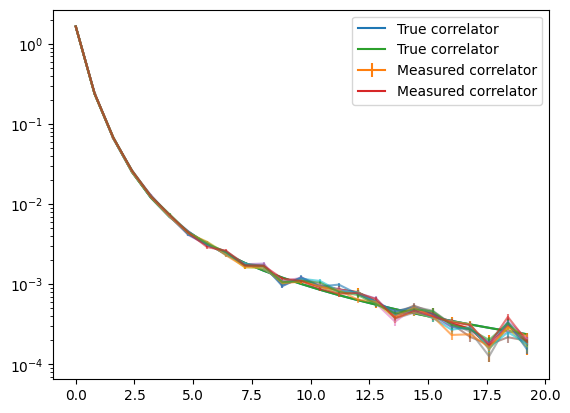

In [6]:
# Preparing the tensor of noise vectors
ep_noise=1e-2
noisy_dxi_tensor = []
num_samples = 10
noisy_Dxi,custom_std=correlator.generateNoisyCorrelator(Dxi,x,ep_noise)
plt.plot(x,Dxi, label=r'True correlator')
plt.errorbar(x,noisy_Dxi,custom_std, label=r'Measured correlator')
ep_noise=5e-3
if num_samples == 1:
    noisy_dxi_tensor.append(noisy_Dxi)
else:
    for ii in range(num_samples):
        noisy_Dxi_sample,custom_std=correlator.generateNoisyCorrelator(noisy_Dxi,x,ep_noise)
        noisy_dxi_tensor.append(noisy_Dxi_sample)


plt.plot(x,Dxi, label=r'True correlator')
plt.errorbar(x,noisy_Dxi, label=r'Measured correlator')
# plt.plot(x,noisy_Dxi, label=r'Noisy correlator')
for i in range(len(noisy_dxi_tensor)):
    plt.errorbar(x, noisy_dxi_tensor[i],custom_std,  alpha=0.6)

plt.yscale('log')

plt.legend()

In [ ]:
# Train the model using the inbuilt `fit`-didn't work beacuse input-output dimensions don't match hence had to write a custom training loop



# Create input data and target
constant_input = tf.constant([[1.0]], dtype=tf.float32)  # Constant input node which goes to 500 omegas as the NN structure in paper
target_output = tf.convert_to_tensor(noisy_dxi_tensor)

#the smothness and rigde regularisation coeffcicients - feel free to modify
lambda_s_warmup = 1.0e-4
lambda_l2_warmup = 1.0e-4
lambda_s = 1.0e-5
lambda_l2 = 0#1.0e-8
epochs=500
new_epochs = 20000

gauss_width = np.ones(len(x)) #for mean square error
model = models.SpectralNN(num_output_nodes=500, width=64, depth=3)
lossCalc=lossCalculator.LossCalculator(model=model,
                                       y_true=target_output,
                                       kernel=kern,
                                       delomega=del_omega,
                                       x=constant_input,
                                       std=gauss_width,
                                       lambda_s_func_warmup=lambda x:lambda_s,
                                       lambda_s_func=lambda x:lambda_s,
                                       lambda_l2_func_warmup=lambda x:lambda_l2,
                                       lambda_l2_func=lambda x:lambda_l2
                                        )
# Compile the model - one can also play with learning rate initially it is kept large to scan through a broader manifold of minima and later decreased
optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
trainer=models.networkTrainer(model,optimizer,lossCalc)
total_loss_history_warmup,loss_history_warmup=trainer.train(epochs,warmup=True,verbose=True)
optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5) #notice the lower learning rate
trainer.optimizer=optimizer
total_loss_history,loss_history=trainer.train(new_epochs,warmup=False,verbose=True)


# gauss_width = np.ones(len(x)) #for mean square error
gauss_width = custom_std #for chi square error
kern=klW_ker_Pos
model_stderror = models.SpectralNN(num_output_nodes=500, width=64, depth=3)
lossCalc=lossCalculator.LossCalculator(model=model_stderror,
                                       y_true=target_output,
                                       kernel=kern,
                                       delomega=del_omega,
                                       x=constant_input,
                                       std=gauss_width,
                                       lambda_s_func_warmup=lambda x:lambda_s_warmup,
                                       lambda_s_func=lambda x:lambda_s,
                                       lambda_l2_func_warmup=lambda x:lambda_l2_warmup,
                                       lambda_l2_func=lambda x:lambda_l2
                                        )
# Compile the model - one can also play with learning rate initially it is kept large to scan through a broader manifold of minima and later decreased
optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
trainer=models.networkTrainer(model_stderror,optimizer,lossCalc)
total_loss_history_warmup,loss_history_warmup=trainer.train(epochs,warmup=True,verbose=True)
optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5) #notice the lower learning rate
trainer.optimizer=optimizer
total_loss_history_stderror,loss_history_stderror=trainer.train(new_epochs,warmup=False,verbose=True)




Training for 500 epochs
Epoch 0, Loss: 744.0287475585938
Epoch 50, Loss: 1.4642434120178223
Epoch 100, Loss: 0.181827113032341
Epoch 150, Loss: 0.10368431359529495
Epoch 200, Loss: 0.06177018582820892
Epoch 250, Loss: 0.03790108487010002
Epoch 300, Loss: 0.023974373936653137
Epoch 350, Loss: 0.015648845583200455
Epoch 400, Loss: 0.010571066290140152
Epoch 450, Loss: 0.007427931297570467
Training took 11.590854406356812 seconds
Training for 20000 epochs
Epoch 0, Loss: 0.005463161040097475
Epoch 2000, Loss: 0.0006161040510050952
Epoch 4000, Loss: 3.380629277671687e-05
Epoch 6000, Loss: 6.091353952797363e-06
Epoch 8000, Loss: 2.536044121370651e-06
Epoch 10000, Loss: 2.0883235265500844e-06
Epoch 12000, Loss: 1.8901266685134033e-06
Epoch 14000, Loss: 1.8411817563901423e-06
Epoch 16000, Loss: 1.82372355084226e-06
Epoch 18000, Loss: 1.8117830222763587e-06
Training took 446.3730170726776 seconds
Training for 500 epochs
Epoch 0, Loss: 747.6611938476562
Epoch 50, Loss: 2.326775074005127
Epoch 10

In [56]:
Final_rhoWNoisy = model(constant_input).numpy().reshape(-1)
Final_DxiWNoisy = correlator.Di(kern,Final_rhoWNoisy,del_omega).numpy().reshape(-1)
Final_rhoWNoisy_stderror = model_stderror(constant_input).numpy().reshape(-1)
Final_DxiWNoisy_stderror = correlator.Di(kern,Final_rhoWNoisy_stderror,del_omega).numpy().reshape(-1)


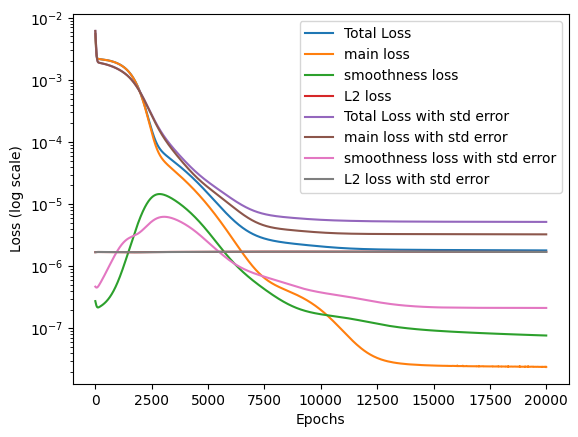

In [57]:
# Plotting loss history
loss_history = np.array(loss_history)
loss_history_stderror = np.array(loss_history_stderror)

trainingepochs=range(new_epochs)

plt.plot(trainingepochs, total_loss_history
         , label='Total Loss')
plt.plot(trainingepochs, loss_history.T[0],label="main loss")
plt.plot(trainingepochs, loss_history.T[1]*lossCalc.get_lambda_s(range(new_epochs),warmup=False),label="smoothness loss")
plt.plot(trainingepochs, 0.5*loss_history.T[2]*lossCalc.get_lambda_l2(range(new_epochs),warmup=False),label="L2 loss")

plt.plot(trainingepochs, total_loss_history_stderror, label='Total Loss with std error')
plt.plot(trainingepochs, loss_history_stderror.T[0],label="main loss with std error")
plt.plot(trainingepochs, loss_history_stderror.T[1]*lossCalc.get_lambda_s(range(new_epochs),warmup=False),label="smoothness loss with std error")
plt.plot(trainingepochs, 0.5*loss_history_stderror.T[2]*lossCalc.get_lambda_l2(range(new_epochs),warmup=False),label="L2 loss with std error")

plt.xlabel('Epochs')
plt.ylabel('Loss (log scale)')
plt.yscale('log') 
plt.legend()
plt.show()

/tmp/ipykernel_165750/3824254080.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(omega,spec2BW/omega, label = r'True function' )


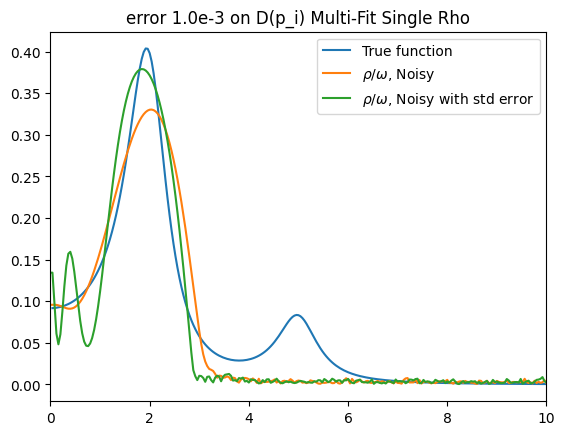

In [68]:
plt.plot(omega,spec2BW/omega, label = r'True function' )
# plt.plot(omega,Final_rhoW, label=r'$\rho/\omega * \omega$')
plt.plot(omega,Final_rhoWNoisy, label=r'$\rho/\omega$, Noisy')
plt.plot(omega,Final_rhoWNoisy_stderror, label=r'$\rho/\omega$, Noisy with std error')
# plt.plot(omega,Final_rhoWNoisySingle, label=r'$\rho/\omega$, Noisy Single')
# plt.plot(omega,Final_rho, label=r'$\rho$')
plt.title(r'error 1.0e-3 on D(p_i) Multi-Fit Single Rho')
plt.legend()
plt.xlim(0,10)
#plt.savefig('NN_Comparison_RhoByOmega_vs_Rho_MultiFitSingleRho10m3.png')
plt.show()

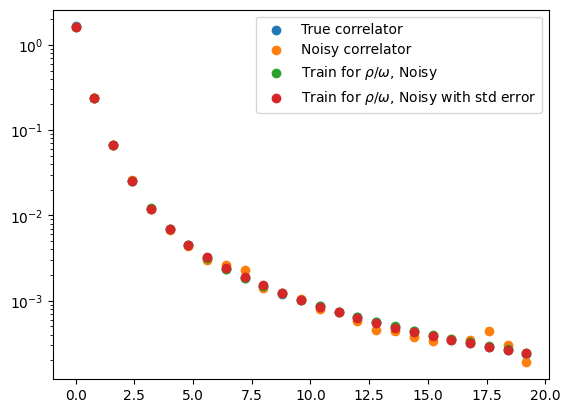

In [59]:
plt.scatter(x,Dxi, label=r'True correlator')
plt.scatter(x,noisy_dxi_tensor[0], label=r'Noisy correlator')
plt.scatter(x,Final_DxiWNoisy, label=r'Train for $\rho/\omega$, Noisy')
plt.scatter(x,Final_DxiWNoisy_stderror, label=r'Train for $\rho/\omega$, Noisy with std error')
plt.yscale('log')
plt.legend()
plt.show()

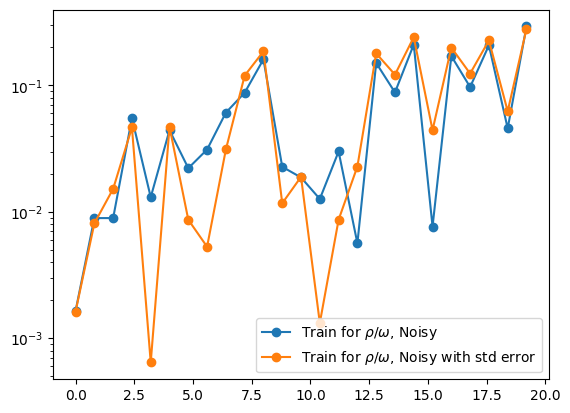

In [66]:
compareCorrelator=noisy_dxi_tensor[0]
plt.plot(x,np.abs(Final_DxiWNoisy-compareCorrelator)/compareCorrelator, label=r'Train for $\rho/\omega$, Noisy',marker='o')
plt.plot(x,np.abs(Final_DxiWNoisy_stderror-compareCorrelator)/compareCorrelator, label=r'Train for $\rho/\omega$, Noisy with std error',marker='o')
plt.yscale('log')
plt.legend()
plt.show()

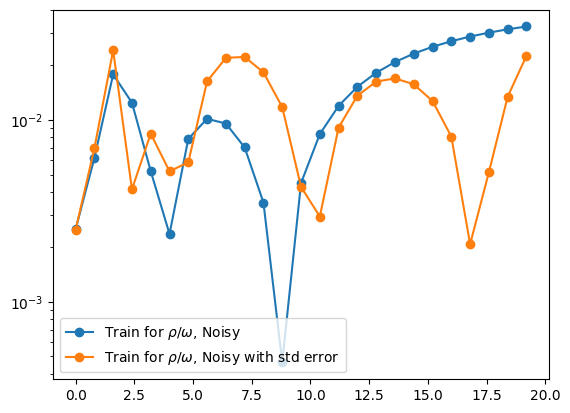

In [67]:
compareCorrelator=Dxi
plt.plot(x,np.abs(Final_DxiWNoisy-compareCorrelator)/compareCorrelator, label=r'Train for $\rho/\omega$, Noisy',marker='o')
plt.plot(x,np.abs(Final_DxiWNoisy_stderror-compareCorrelator)/compareCorrelator, label=r'Train for $\rho/\omega$, Noisy with std error',marker='o')
plt.yscale('log')
plt.legend()
plt.show()

# Behaviour of the kernal with $\omega$ and $p$.  

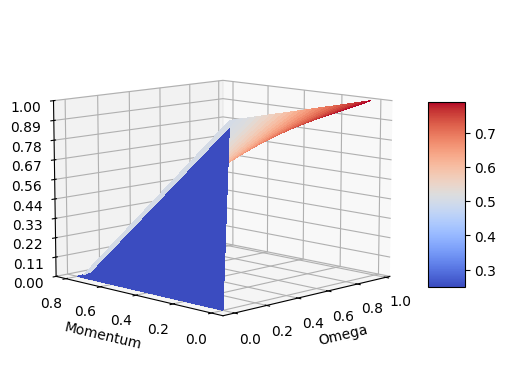

In [ ]:
from matplotlib import cm
from matplotlib.ticker import LinearLocator

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Make data X = Omega, Y = momentum.
X = np.arange(0, 1, 0.04)
Y = np.arange(epsilon, 1+epsilon, del_pi)
X, Y = np.meshgrid(X, Y)
R = X**2 + Y**2
Z = X**2/R

plt.xlabel('Omega')
plt.ylabel('Momentum')
# Plot the surface.
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

# Customize the z axis.
ax.set_zlim(0, 1)
ax.zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter('{x:.02f}')

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)

ax.view_init(elev=10, azim=225) 

plt.show()

# Bootstrapping
Here we want to generate many spectral functions corresponding to different noisy instances of the correlator and then bootstrap over these samples, which are then to be compared to the other approach.

In [ ]:
# new custom class iheriting from base class - here structure is added to simple layers above
class CustomTrainingModel(SpectralNN):
    def __init__(self, num_output_nodes, width=64, depth=3, lambda_s=None, lambda_l2=None, kl_ker=None, del_omega=None, gauss_width=None):
        super(CustomTrainingModel, self).__init__(num_output_nodes, width, depth)
        self.lambda_s = lambda_s
        self.lambda_l2 = lambda_l2
        self.kl_ker = kl_ker
        self.del_omega = del_omega
        self.gauss_width = gauss_width
    
    def compute_predictions(self, x):
        return self(x, training=True)
    
    def train_step(self, data):
        x, y = data  # Only unpack x and y (because Keras only passes two values)
        
        with tf.GradientTape() as tape:
            # Forward pass: Compute predictions - Gradient tape keeps track of gradients to allow explicit automatic differentiation
            rhoi_predN = self.compute_predictions(x)
            
            # Reconstruct correlator using external Di function (using stored kl_ker and del_omega)
            y_predN = Di(self.kl_ker, rhoi_predN, self.del_omega)
            
            # Compute custom loss (including smoothness and L2 regularization)
            loss = custom_loss(y, y_predN, gauss_width)
            total_loss_value = total_loss(loss, rhoi_predN, self, self.lambda_s, self.lambda_l2)  # Include smoothness and L2 terms
        
        # Compute gradients and update weights
        gradients = tape.gradient(total_loss_value, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))
        
        return {"loss": total_loss_value}

# Create input data and target
constant_input = tf.constant([[1.0]], dtype=tf.float32)  # Constant input node which goes to 500 omegas as the NN structure in paper
target_output = tf.convert_to_tensor(noisy_dpi_tensor)

#the smothness and rigde regularisation coeffcicients - feel free to modify
lambda_s = 1.0e-3
lambda_l2 = 1.0e-6
gauss_width = np.ones(25) #for mean square error
#gauss_width = custom_std #for chi square error

# Initialize the model
# Compile the model - one can also play with learning rate initially it is kept large to scan through a broader manifold of minima and later decreased

In [ ]:
#The actual training loops
output_rho_tensor = []
output_Dpi_tensor = []

for ii in range(target_output.shape[0]):
    print('\n',ii,'\n')
    model = CustomTrainingModel(num_output_nodes=500, width=64, depth=3, lambda_s=lambda_s, lambda_l2=lambda_l2, kl_ker=klW_ker, del_omega=del_omega, gauss_width=gauss_width)
    
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
    
    epochs=2000
# Custom Training Loop for the smootheness part (called "Warm up loop" in the paper)
    for epoch in range(epochs):

        with tf.GradientTape() as tape:
        # Forward pass: Compute predictions
            rhoi_pred = model(constant_input) # Shape 500
        
        # Reconstruct correlator using Di function
            y_pred = Di(kl_ker, rhoi_pred, del_omega)  # Shape 25
        
            main_loss += custom_loss(target_output[ii], y_pred, gauss_width)

            total_loss_value = total_loss(main_loss, rhoi_pred, model, lambda_s, lambda_l2) 
    
    # Compute gradients and update weights
        gradients = tape.gradient(total_loss_value, model.trainable_weights)
        optimizer.apply_gradients(zip(gradients, model.trainable_weights))
    
    #print(f"Loss: {total_loss_value.numpy()}")

    print("Warm up complete.")

    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5) #notice the lower learning rate
    new_epochs = 10000
    loss_history = []
    for epoch in range(new_epochs):
    #print(f'Resuming Epoch {epoch + 1}/{new_epochs}')
    
        with tf.GradientTape() as tape:
        # Forward pass: Compute predictions
            rhoi_pred = model(constant_input) # Shape 500
        
        # Reconstruct correlator using Di function
            y_pred = Di(kl_ker, rhoi_pred, del_omega)  # Shape 25
        
            main_loss += custom_loss(target_output[ii], y_pred, gauss_width)
  
            total_loss_value = total_loss(main_loss, rhoi_pred, model, lambda_s=0, lambda_l2=1.0e-8)
    
    # Compute gradients and update weights
        gradients = tape.gradient(total_loss_value, model.trainable_weights)
        optimizer.apply_gradients(zip(gradients, model.trainable_weights))

    #print(f"Loss: {total_loss_value.numpy()}")
        loss_history.append(total_loss_value.numpy())

    Final_rho_FT = rhoi_pred.numpy().reshape(-1)
    Final_Dpi_FT = y_pred.numpy().reshape(-1)
    output_rho_tensor.append(Final_rho_FT)
    output_Dpi_tensor.append(Final_Dpi_FT)
    print("Training complete for additional epochs.")





 0 

Warm up complete.
Training complete for additional epochs.

 1 

Warm up complete.
Training complete for additional epochs.

 2 

Warm up complete.
Training complete for additional epochs.

 3 

Warm up complete.
Training complete for additional epochs.

 4 

Warm up complete.
Training complete for additional epochs.

 5 

Warm up complete.
Training complete for additional epochs.

 6 

Warm up complete.
Training complete for additional epochs.

 7 

Warm up complete.
Training complete for additional epochs.

 8 

Warm up complete.
Training complete for additional epochs.

 9 

Warm up complete.
Training complete for additional epochs.

 10 

Warm up complete.
Training complete for additional epochs.

 11 

Warm up complete.
Training complete for additional epochs.

 12 

Warm up complete.
Training complete for additional epochs.

 13 

Warm up complete.
Training complete for additional epochs.

 14 

Warm up complete.
Training complete for additional epochs.

 15 

Warm up compl

In [ ]:
output_rho = tf.convert_to_tensor(output_rho_tensor,dtype=tf.float32)
output_Dpi = tf.convert_to_tensor(output_Dpi_tensor,dtype=tf.float32)

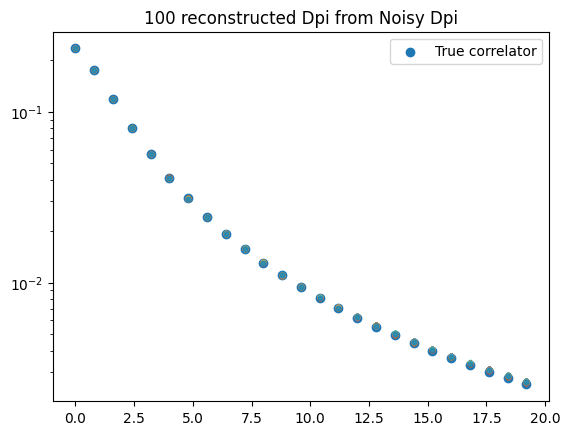

In [ ]:
plt.scatter(p,Dpi, label=r'True correlator')
for i in range(100):
    plt.scatter(p, output_Dpi[i], s=10, alpha=0.6)

plt.title(r'100 reconstructed Dpi from Noisy Dpi')
plt.yscale('log')

plt.legend()
#plt.savefig('NN_ReconstructedCorrelator_1BW_100Machines100outputsL21em6.png')
plt.show()

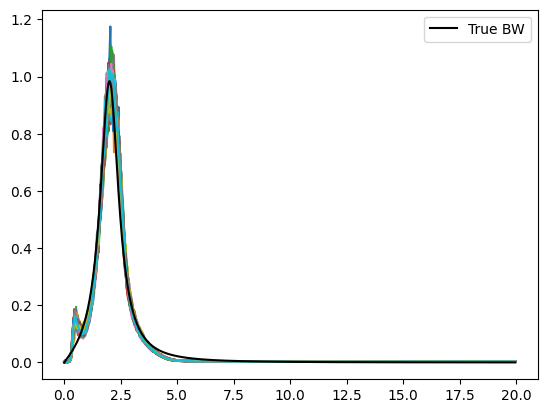

In [ ]:
for i in range(100):
    plt.plot(omega, output_rho[i])
plt.plot(omega,spec1BW,color='black', label=r'True BW')
#plt.plot(omega,Final_rho,'-.r', label=r'Multi Fit Single $\rho$')
plt.legend()
#plt.savefig('Comp_NN_ReconstructedRho_1BW_100Machines100outputsL21em6.png')
plt.show()

In [ ]:
#Bootstrap analysis
# Number of bootstrap samples to generate
output_rho_np = output_rho.numpy()
n_bootstrap_samples = 1000
bootstrap_means = []
# Generate bootstrap samples
for _ in range(n_bootstrap_samples):
    
    bootstrap_sample = output_rho_np[np.random.choice(output_rho_np.shape[0], size=output_rho_np.shape[0], replace=True)]
    bootstrap_mean = np.mean(bootstrap_sample, axis=0, keepdims=True)
    bootstrap_means.append(bootstrap_mean)

# Convert to NumPy array for analysis
bootstrap_means = np.array(bootstrap_means)

# Estimate the error (standard deviation of bootstrap means)
bootstrap_error = np.std(bootstrap_means,axis=0)


In [ ]:
np.shape(bootstrap_means), np.shape(bootstrap_error), np.shape(MeanMean)
#test = tf.convert_to_tensor(bootstrap_samples)
#tf.shape(test)
#bootstrap_means = np.squeeze(bootstrap_means, axis=1)
#bootstrap_error = bootstrap_error.reshape(500)
#MeanMean = np.mean(bootstrap_means,axis=0)

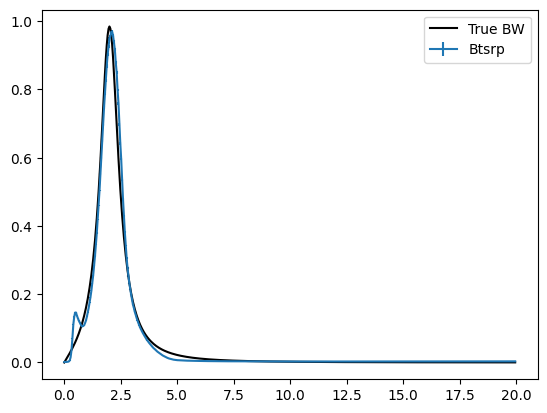

In [ ]:
plt.errorbar(omega, MeanMean, yerr=bootstrap_error, label=r'Btsrp')
plt.plot(omega,spec1BW,color='black', label=r'True BW')
#plt.plot(omega,Final_rho,color='red', label=r'Multi Fit Single $\rho$')
plt.legend()
#plt.savefig('NN_ReconstructedCorrelator_10Kepochs1BW1e-3.png')
plt.show()